# 客户流失预测 - EDA

## 1. 加载数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

os.makedirs('images', exist_ok=True)

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

print(f'Train: {train.shape}, Test: {test.shape}')
display(train.head())
display(train.describe())

Train: (165034, 14), Test: (110023, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


## 2. 缺失值检查

In [2]:
missing = train.isnull().sum() / len(train) * 100
missing = missing[missing > 0]
print('缺失率(%):'); display(missing)
print('数据类型:'); display(train.dtypes)

缺失率(%):


Series([], dtype: float64)

数据类型:


id                   int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object

## 3. 目标变量分布

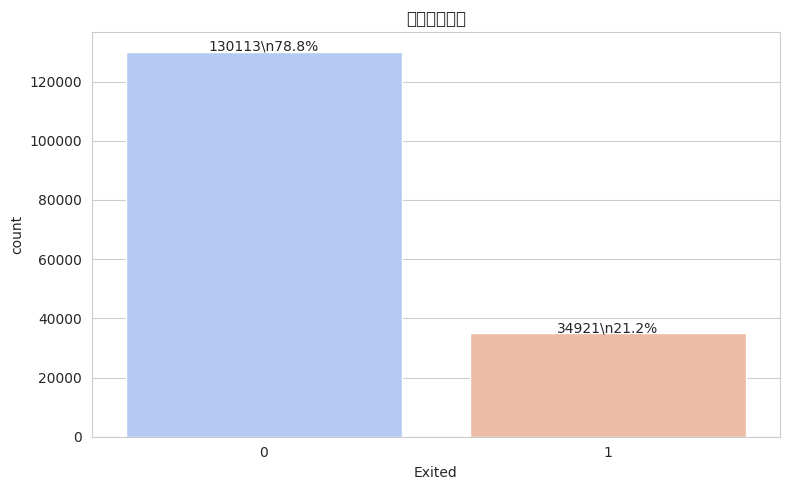

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Exited', data=train, palette='coolwarm')
cnt = train.Exited.value_counts()
pct = train.Exited.value_counts(normalize=True) * 100
for i, (v, p) in enumerate(zip(cnt, pct)):
    ax.text(i, v+200, f'{v}\\n{p:.1f}%', ha='center')
plt.title('目标变量分布')
plt.tight_layout()
plt.savefig('images/target_dist.png', dpi=300)
plt.show()

## 4. 类别特征分析

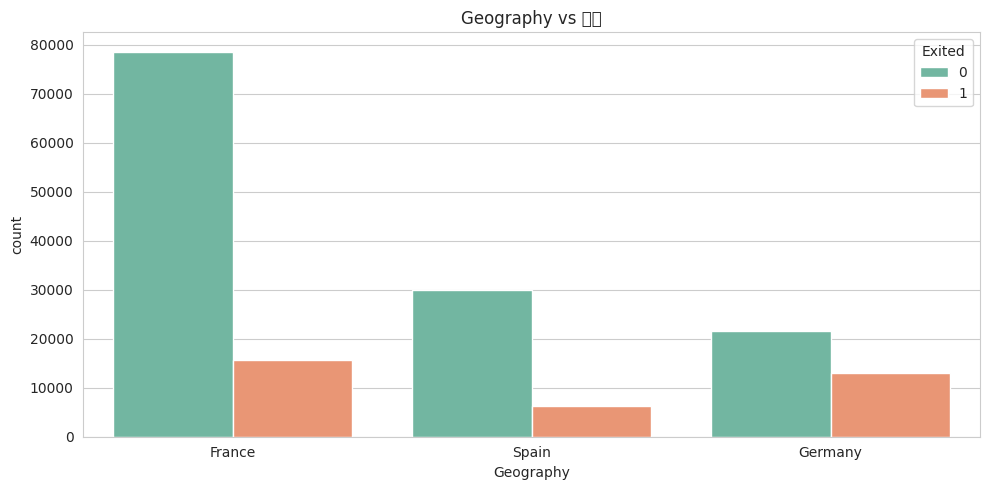

Geography 流失率(%):


Geography
France     16.53
Germany    37.90
Spain      17.22
Name: Exited, dtype: float64

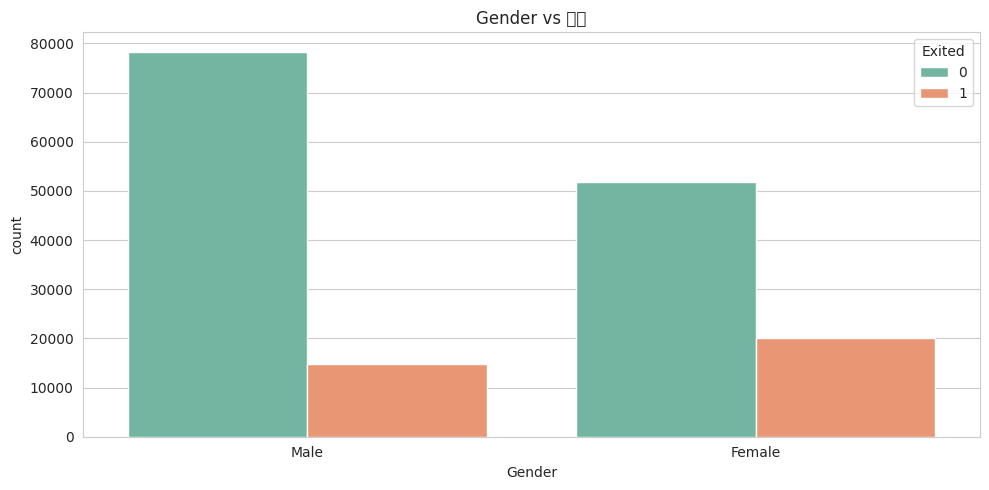

Gender 流失率(%):


Gender
Female    27.97
Male      15.91
Name: Exited, dtype: float64

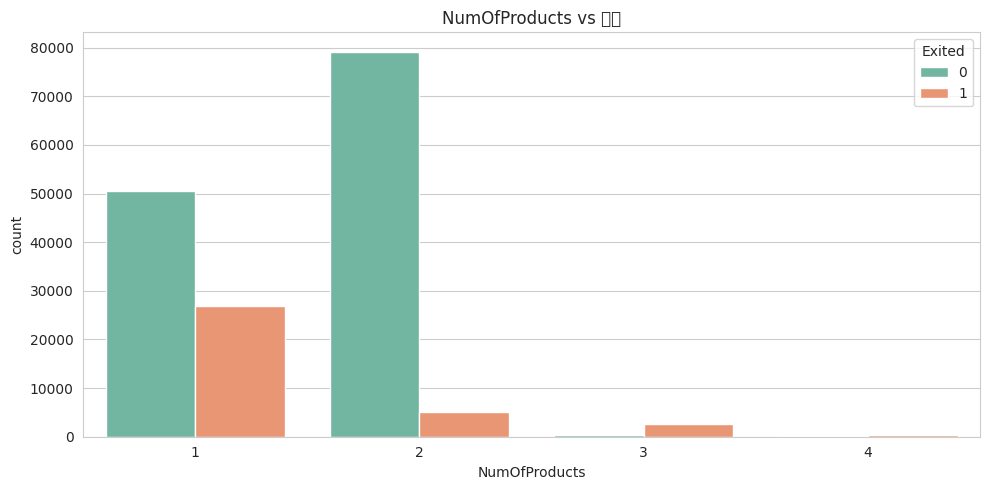

NumOfProducts 流失率(%):


NumOfProducts
1    34.71
2     6.04
3    88.25
4    87.58
Name: Exited, dtype: float64

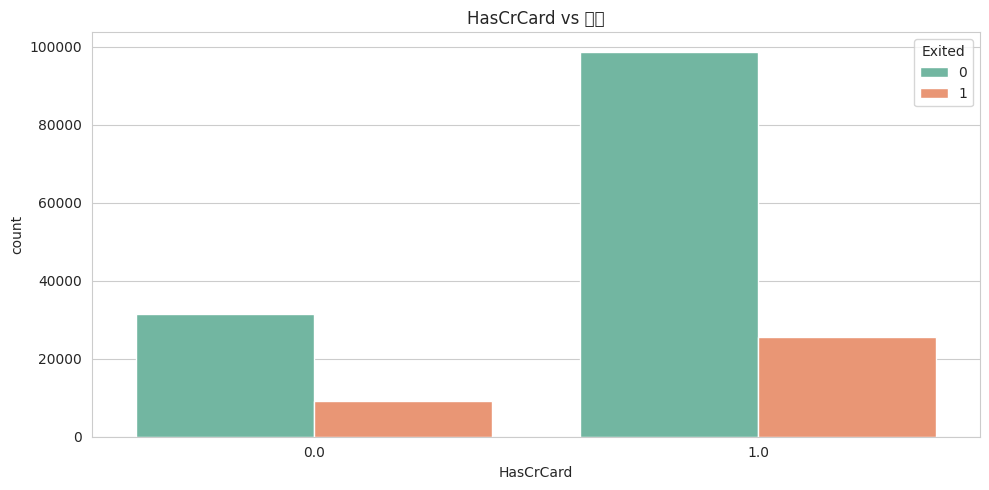

HasCrCard 流失率(%):


HasCrCard
0.0    22.74
1.0    20.64
Name: Exited, dtype: float64

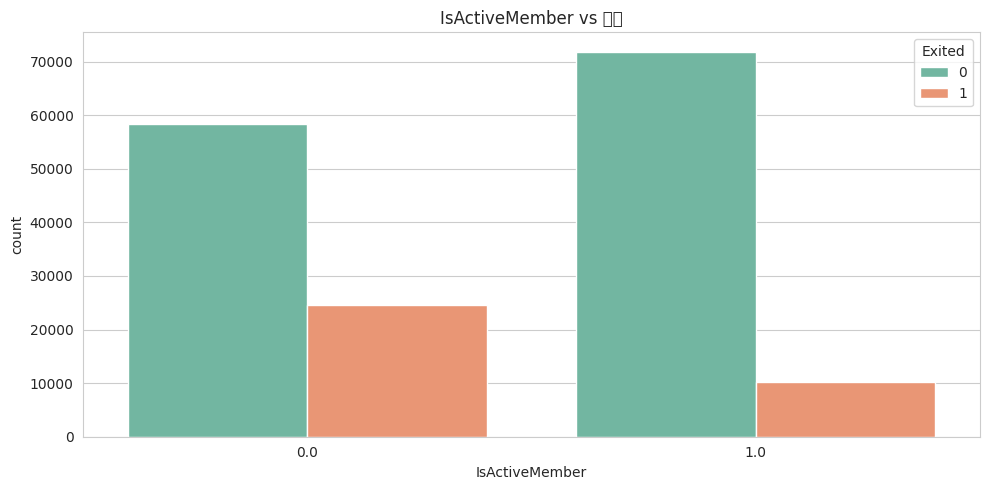

IsActiveMember 流失率(%):


IsActiveMember
0.0    29.71
1.0    12.53
Name: Exited, dtype: float64

In [4]:
cat_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='Exited', data=train, palette='Set2')
    plt.title(f'{col} vs 流失')
    plt.tight_layout()
    plt.savefig(f'images/cat_{col}.png', dpi=300)
    plt.show()
    print(f'{col} 流失率(%):'); display((train.groupby(col)['Exited'].mean()*100).round(2))

## 5. 数值特征分析

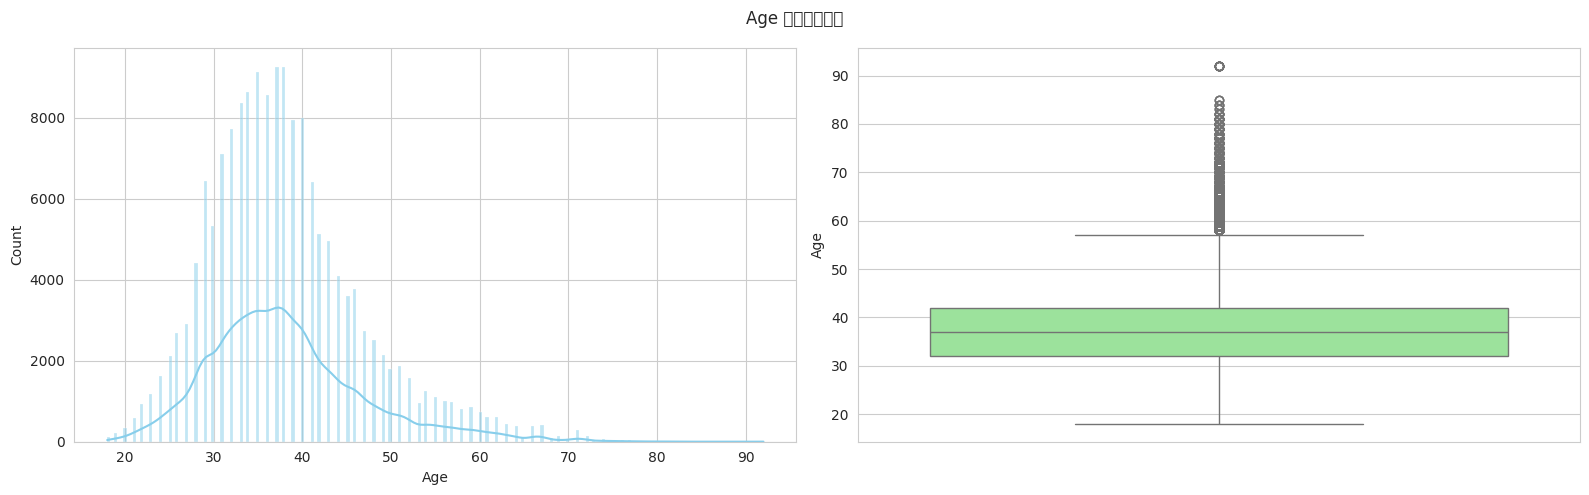

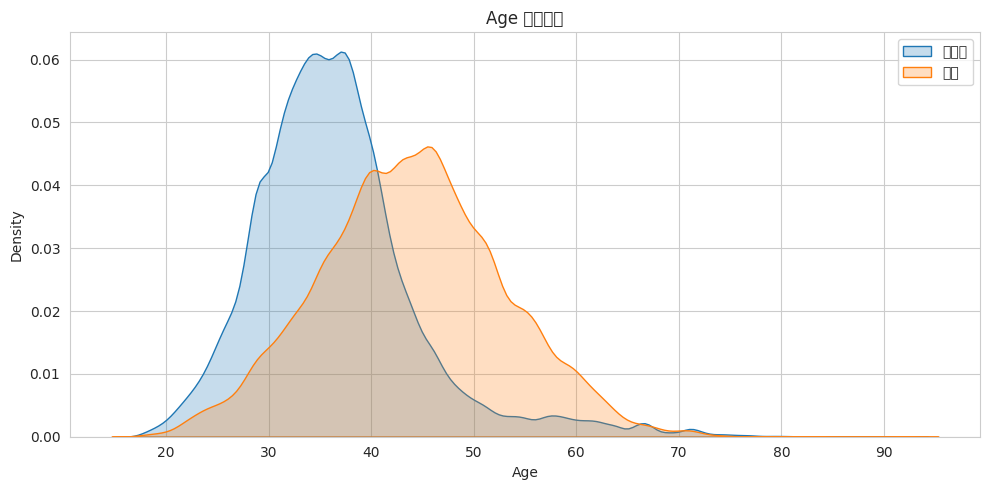

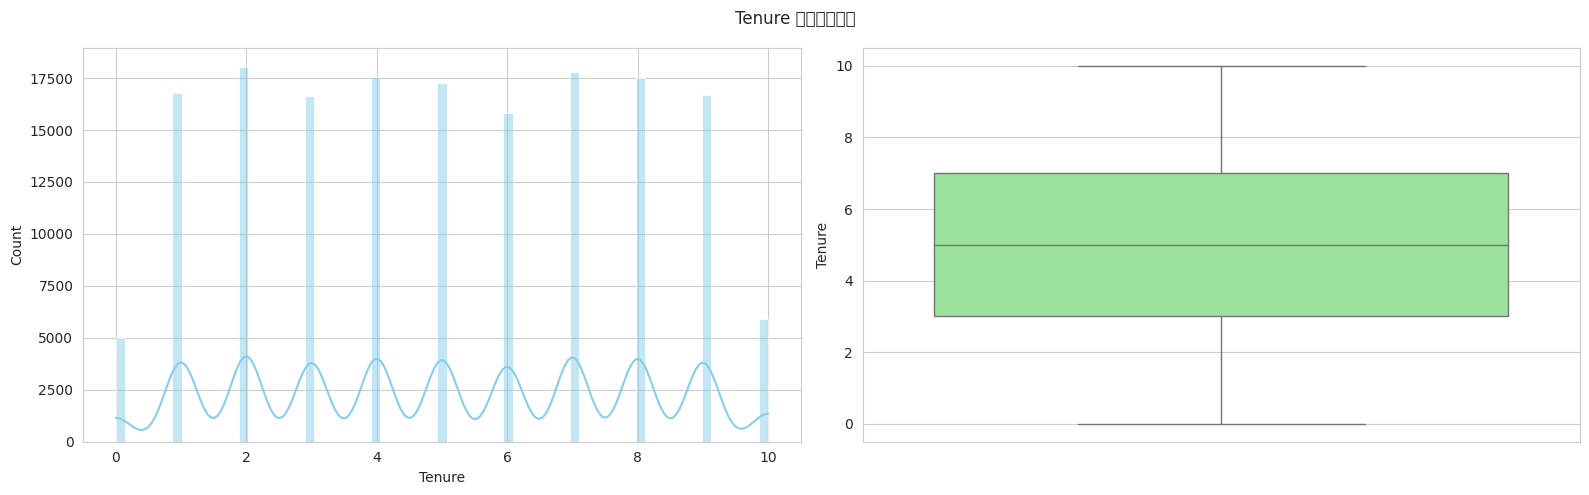

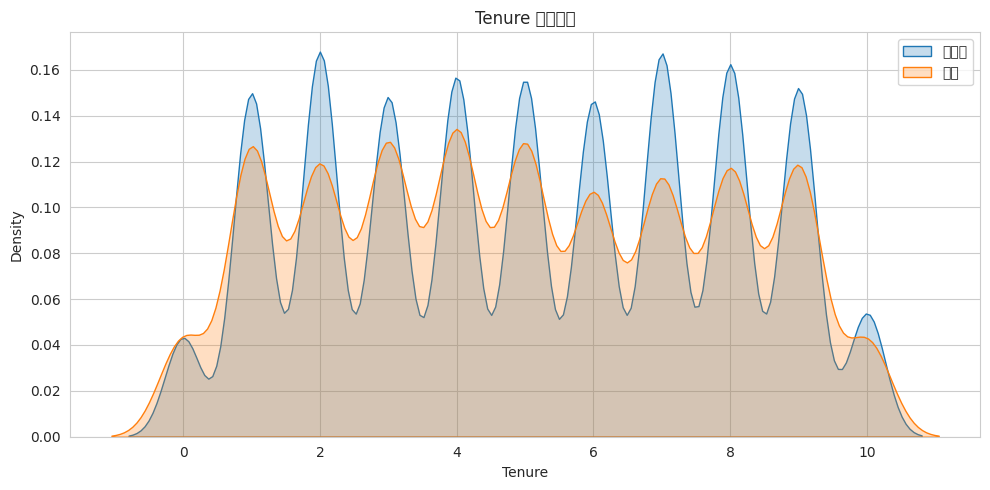

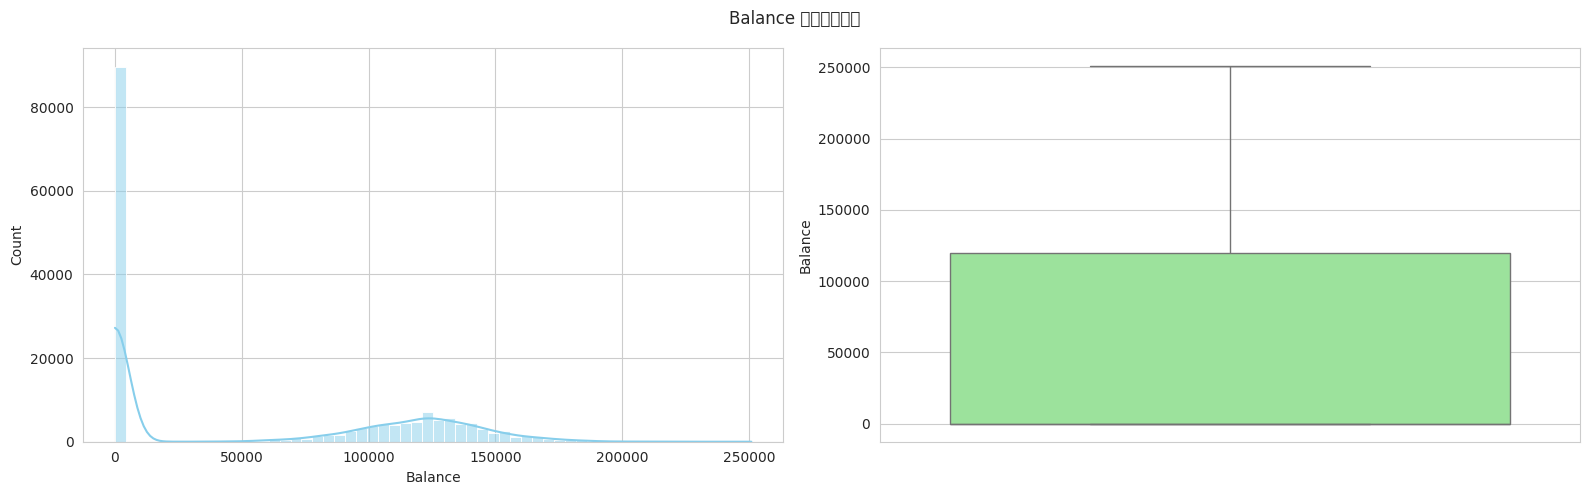

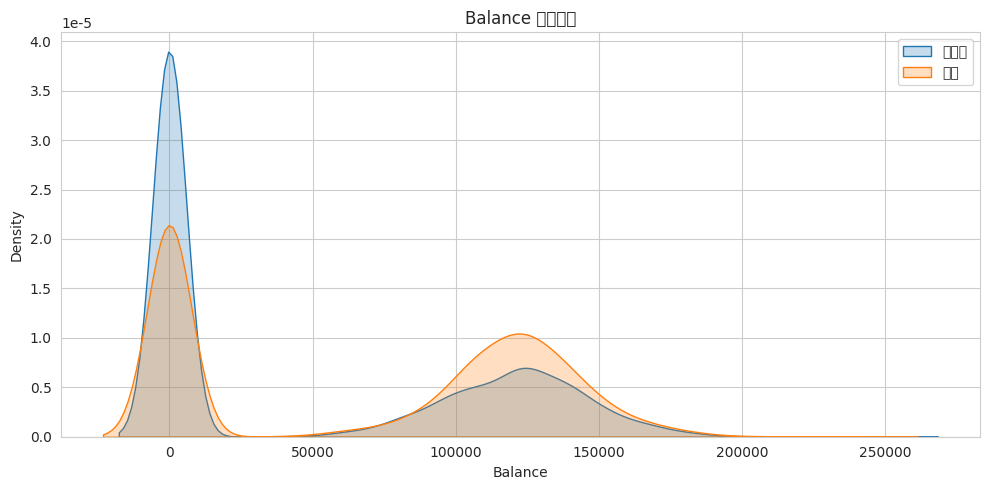

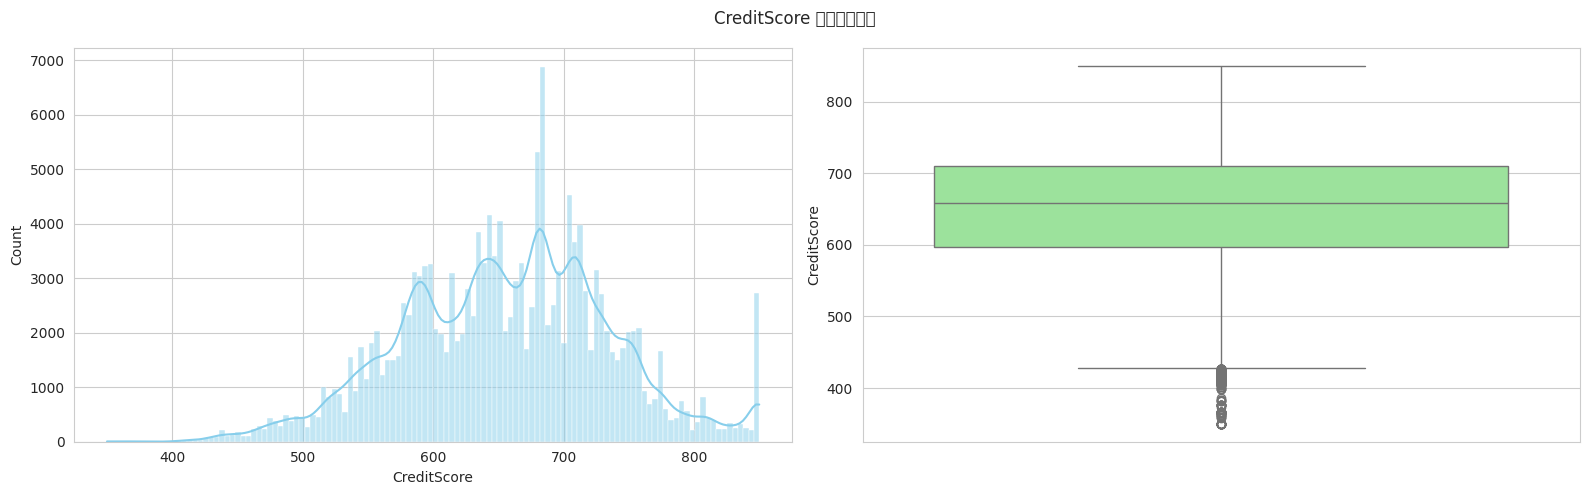

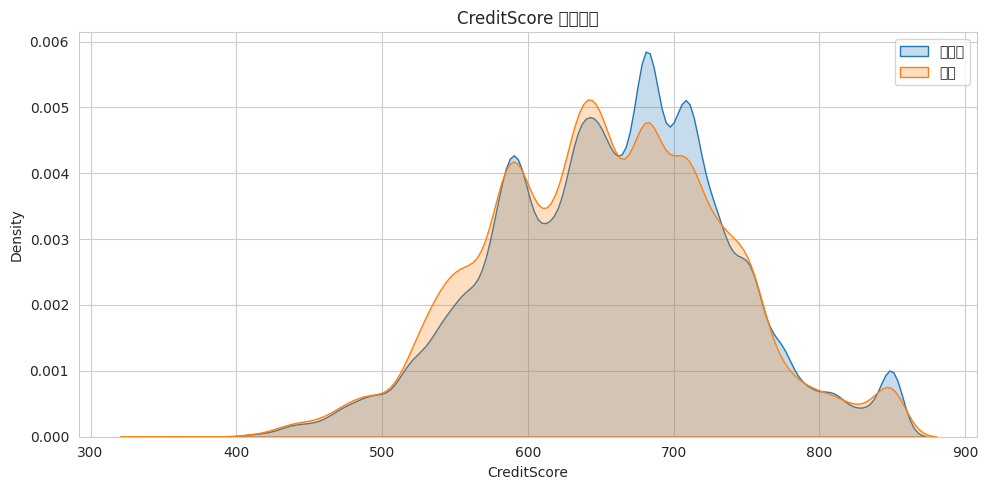

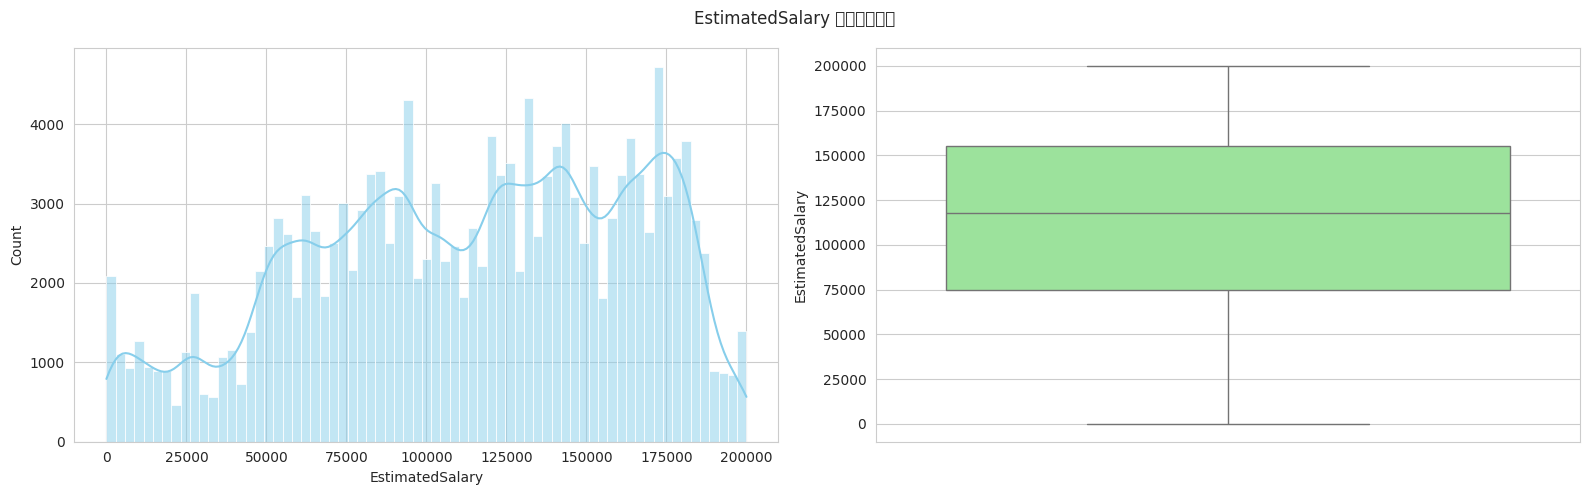

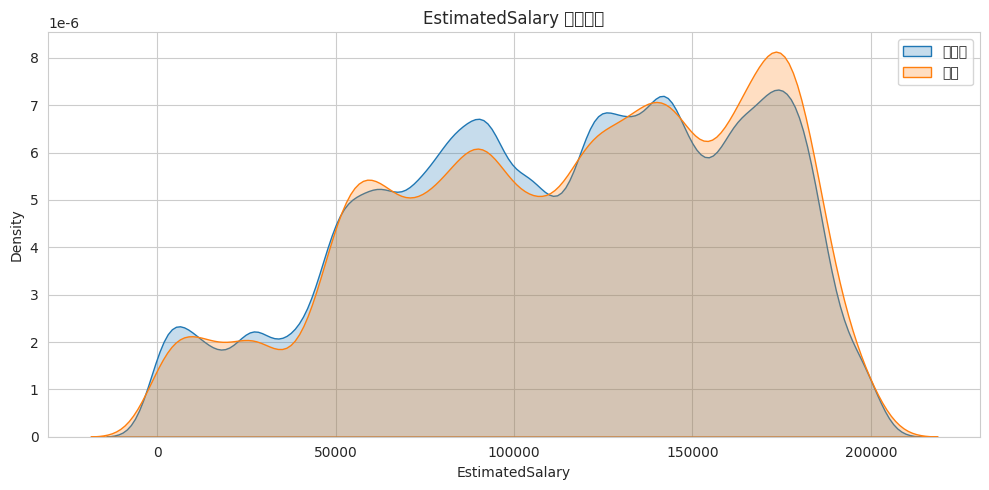

In [5]:
num_cols = ['Age', 'Tenure', 'Balance', 'CreditScore', 'EstimatedSalary']
for col in num_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    sns.histplot(train[col], kde=True, ax=ax1, color='skyblue')
    sns.boxplot(y=col, data=train, ax=ax2, color='lightgreen')
    plt.suptitle(f'{col} 分布与异常值')
    plt.tight_layout()
    plt.savefig(f'images/num_dist_{col}.png', dpi=300)
    plt.show()
    
    plt.figure(figsize=(10, 5))
    sns.kdeplot(train[train.Exited==0][col], label='未流失', fill=True)
    sns.kdeplot(train[train.Exited==1][col], label='流失', fill=True)
    plt.title(f'{col} 流失对比')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'images/num_kde_{col}.png', dpi=300)
    plt.show()

## 6. 相关性分析

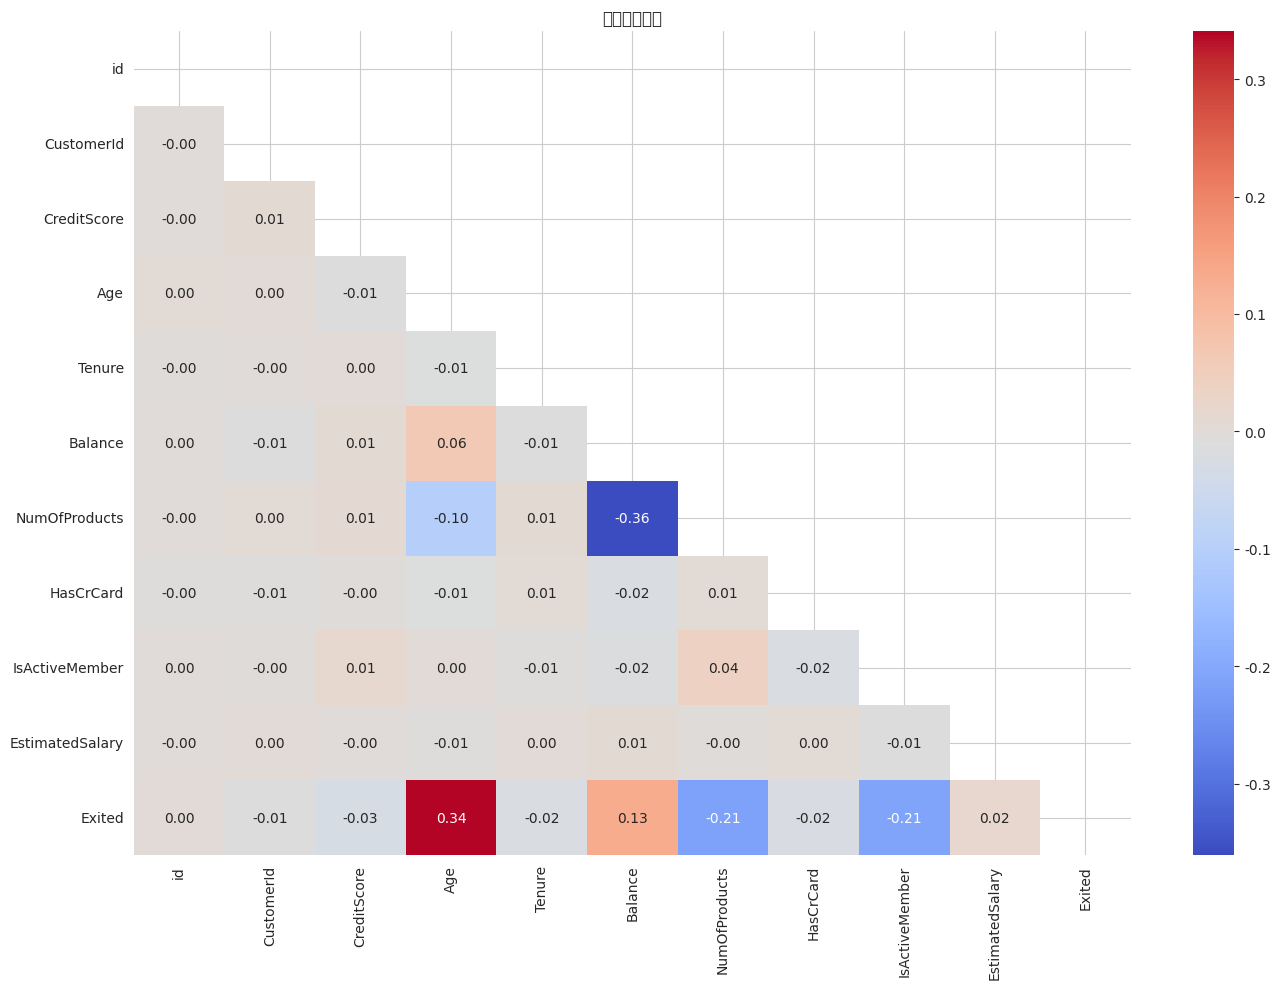

与流失相关性排序:


Age                0.341
NumOfProducts      0.215
IsActiveMember     0.210
Balance            0.130
CreditScore        0.027
HasCrCard          0.022
Tenure             0.020
EstimatedSalary    0.019
CustomerId         0.010
Name: Exited, dtype: float64

In [6]:
plt.figure(figsize=(14, 10))
corr = train.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('相关性热力图')
plt.tight_layout()
plt.savefig('images/correlation.png', dpi=300)
plt.show()

print('与流失相关性排序:'); display(corr.Exited.abs().sort_values(ascending=False)[1:10].round(3))